In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtr, ndtri  # vectorized normal CDF / inverse CDF

# Part 1 - Bayesian Regret

In [2]:
np.random.seed(592)

In [3]:
simulations = 50
K = 10
# variance is 1
true_prior = [0 for _ in range(K)]
wrong_prior = [1/K for _ in range(K)] # uniform distribution
n = [100, 1000, 10000]

## TS using well-specified/true prior P

In [4]:
def thompson_sampling_well_specified(K, n):
    """
    Thompson Sampling with well-specified Gaussian prior N(0, I_K).
    Prior: mu_i~N(0, 1)
    Likelihood: r| mu_i ~ N(mu_i, 1)
    Posterior: mu_i | data ~ N(S_i / (1 + N_i), 1 / (1 + N_i))
    Returns : cumulative Bayes regret for this simulation
    """
    
    # sample true environment from prior
    true_means = np.random.normal(0, 1, K)
    optimal_mean = np.max(true_means)
    
    # posterior parameters (start at prior)
    post_means = np.zeros(K)  # prior mean = 0
    post_vars = np.ones(K)    # prior var = 1
    noise_var = 1.0
    
    N_i = np.zeros(K)
    S_i = np.zeros(K)
    
    cumulative_regret = 0.0
    
    for t in range(n):
        # sample from posterior for each arm
        samples = np.random.normal(post_means, np.sqrt(post_vars))
        
        # pick arm with highest sampled mean
        arm = np.argmax(samples)
        
        # observe reward
        reward = np.random.normal(true_means[arm], np.sqrt(noise_var))
        
        # accumulate regret
        cumulative_regret += optimal_mean - true_means[arm]
        
        # update sufficient statistics
        N_i[arm] += 1
        S_i[arm] += reward
        
        # update posterior: N(S_i / (1 + N_i), 1 / (1 + N_i))
        post_vars[arm] = 1.0 / (1.0 + N_i[arm])
        post_means[arm] = S_i[arm] / (1.0 + N_i[arm])
    
    return cumulative_regret

## TS with misspecified prior P' = Uniform([-1,1]^K)

In [5]:
def sample_truncnorm_vec(post_mean, post_std, low=-1.0, high=1.0):
    """
    Vectorized truncated normal sampling via inverse CDF method.
    Uses scipy's ndtr (normal CDF) and ndtri (inverse normal CDF)
    for fast, exact sampling without rejection.
    (previous iteration of this assignment did not include this and resulted in code 
    running for over 10 minutes)
    """
    a = (low - post_mean) / post_std
    b = (high - post_mean) / post_std
    Phi_a = ndtr(a)
    Phi_b = ndtr(b)
    u = np.random.uniform(Phi_a, Phi_b)
    u = np.clip(u, 1e-10, 1 - 1e-10)  # numerical safety, reduces crashes
    return post_mean + post_std * ndtri(u)


def thompson_sampling_misspecified(K, n):
    """
    Thompson Sampling with misspecified Uniform[-1,1] prior.
    True environment is still sampled from N(0, I_K).
    
    Prior: mu_i ~ Uniform(-1, 1)
    Likelihood: r | mu_i ~ N(mu_i, 1)
    Posterior:mu_i | data ~ TruncatedNormal(S_i/N_i, 1/N_i, -1, 1)
    
    Returns: cumulative Bayes regret for this simulation
    """
    # sample true environment from the TRUE prior N(0, I_K) as per hw instructions
    true_means = np.random.normal(0, 1, K)
    optimal_mean = np.max(true_means)
    
    noise_var = 1.0
    
    # sufficient statistics
    N_i = np.zeros(K)
    S_i = np.zeros(K)
    
    cumulative_regret = 0.0
    
    for t in range(n):
        pulled = N_i > 0
        samples = np.empty(K)
        
        # Unpulled arms: sample from prior Uniform[-1, 1]
        n_unpulled = np.sum(~pulled)
        if n_unpulled > 0:
            samples[~pulled] = np.random.uniform(-1, 1, size=n_unpulled)
        
        # Pulled arms: sample from truncated normal posterior
        if np.any(pulled):
            post_mean = S_i[pulled] / N_i[pulled]
            post_std = np.sqrt(1.0 / N_i[pulled])
            samples[pulled] = sample_truncnorm_vec(post_mean, post_std)
        
        arm = np.argmax(samples)
        reward = np.random.normal(true_means[arm], np.sqrt(noise_var))
        
        cumulative_regret += optimal_mean - true_means[arm]
        
        N_i[arm] += 1
        S_i[arm] += reward
    
    return cumulative_regret

## Run Part I Simulations

In [6]:
n_values = [100, 1000, 10000]

bayes_regret_ws = []
bayes_regret_ms = []

for horizon in n_values:
    regrets_ws = []
    regrets_ms = []
    
    for sim in range(simulations):
        r_ws = thompson_sampling_well_specified(K, horizon)
        
        r_ms = thompson_sampling_misspecified(K, horizon)
        
        regrets_ws.append(r_ws)
        regrets_ms.append(r_ms)
    
    avg_ws = np.mean(regrets_ws)
    avg_ms = np.mean(regrets_ms)
    bayes_regret_ws.append(avg_ws)
    bayes_regret_ms.append(avg_ms)
    
    print(f'n={horizon:>6d} | Well-specified BR: {avg_ws:.2f} | Misspecified BR: {avg_ms:.2f}')

n=   100 | Well-specified BR: 41.10 | Misspecified BR: 48.03
n=  1000 | Well-specified BR: 66.47 | Misspecified BR: 82.11
n= 10000 | Well-specified BR: 104.37 | Misspecified BR: 185.74


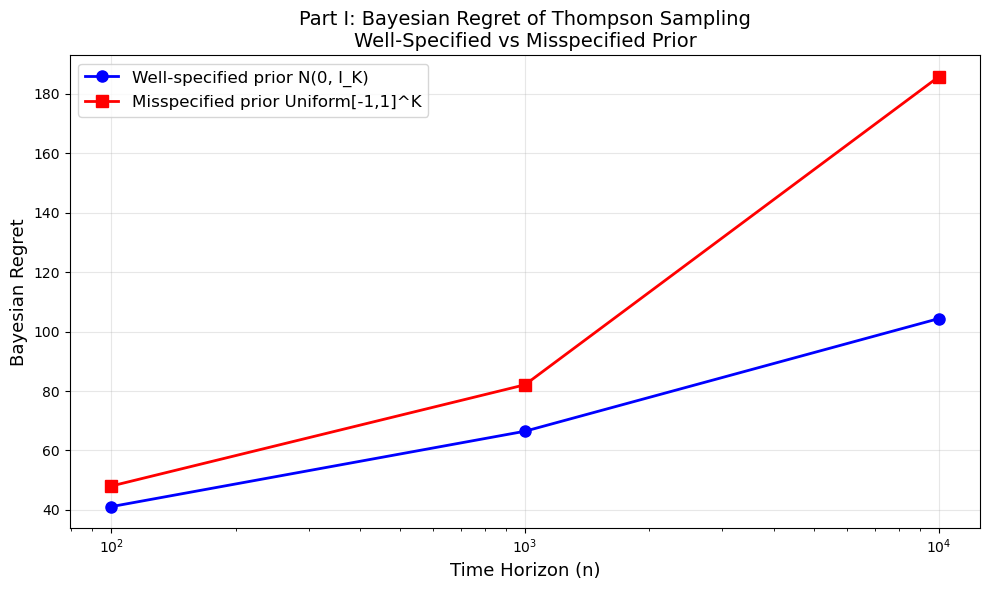

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(n_values, bayes_regret_ws, 'bo-', label='Well-specified prior N(0, I_K)', 
         linewidth=2, markersize=8)
plt.plot(n_values, bayes_regret_ms, 'rs-', label='Misspecified prior Uniform[-1,1]^K', 
         linewidth=2, markersize=8)
plt.xlabel('Time Horizon (n)', fontsize=13)
plt.ylabel('Bayesian Regret', fontsize=13)
plt.title('Part I: Bayesian Regret of Thompson Sampling\nWell-Specified vs Misspecified Prior', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

## Part I: Analysis

**Posterior Sampling Rules:**

1. **Well-Specified Prior** (P = N(0_K, I_K)):  
   At each round, for each arm i, sample theta_i ~ N(S_i/(1+N_i), 1/(1+N_i)) where S_i is the cumulative reward and N_i is the number of pulls. Play argmax_i theta_i.

2. **Misspecified Prior** (P' = Uniform([-1,1]^K)):  
   At each round, for each arm i with N_i > 0 pulls, sample theta_i from a Truncated Normal on [-1,1] with mean S_i/N_i and variance 1/N_i (using the inverse CDF method). For unpulled arms, sample from Uniform(-1,1). Play argmax_i theta_i.

**Observations:**
- The Bayes Regret under the misspecified prior is higher than under the well-specified prior. For smaller horizons, the difference between the priors in TS is not that large. I imagine that if the time horizon was larger than 10^4, then we would see the performance of TS under the misspecified prior degrade further.
- I would say that the misspecified prior is not competitive in comparison to the well-specified prior.

---
# Part 2 - Frequentist Regret

In [8]:
n_freq = 2000
num_sims = 10
deltas = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

## UCB Implementation

    A_t = argmax_i [ mu_hat_i(t-1) + sqrt(2 * log(f(t)) / T_i(t-1)) ]

where f(t) = 1 + t * log^2(t).

In [9]:
def ucb_algorithm(true_means, n, K):
    """
    UCB algorithm for K-armed Gaussian bandit.
    Confidence bound from Lecture 9:
        mu_hat_i + beta * sqrt(2 * log(2*K*n / delta) / T_i)
    with beta = 1 (1-subgaussian) and delta = 1/n.
    """
    optimal_mean = np.max(true_means)
    beta = 1.0  # rewards are 1-subgaussian (Gaussian with variance 1)
    delta = 1.0 / n

    N_i = np.zeros(K)
    S_i = np.zeros(K)
    cumulative_regret = 0.0

    # pull each arm once
    for i in range(K):
        reward = np.random.normal(true_means[i], 1.0)
        N_i[i] = 1
        S_i[i] = reward
        cumulative_regret += optimal_mean - true_means[i]

    # subsequent rounds
    for t in range(K, n):
        mu_hat = S_i / N_i
        ucb_values = mu_hat + beta * np.sqrt(2 * np.log(2 * K * n / delta) / N_i)

        arm = np.argmax(ucb_values)
        reward = np.random.normal(true_means[arm], 1.0)

        cumulative_regret += optimal_mean - true_means[arm]
        N_i[arm] += 1
        S_i[arm] += reward

    return cumulative_regret

## Thompson Sampling Implementation (Frequentist Setting)

In [10]:
def thompson_sampling_freq(true_means, n, K):
    """
    Thompson Sampling for K-armed Gaussian bandit with N(0,1) prior.
    
    Prior: mu_i ~ N(0, 1)
    Likelihood: r | mu_i ~ N(mu_i, 1)
    Posterior: mu_i | data ~ N(S_i / (1 + N_i), 1 / (1 + N_i))
    """
    optimal_mean = np.max(true_means)
    
    N_i = np.zeros(K)
    S_i = np.zeros(K)
    noise_var = 1.0
    prior_mean = 0.0
    prior_var = 1.0
    
    cumulative_regret = 0.0
    
    for t in range(n):
        # compute posterior parameters
        post_vars = 1.0 / (1.0 / prior_var + N_i / noise_var)
        post_means = post_vars * (prior_mean / prior_var + S_i / noise_var)
        
        # arms never pulled use the prior
        not_pulled = (N_i == 0)
        post_means[not_pulled] = prior_mean
        post_vars[not_pulled] = prior_var
        
        # sample from posterior and pick best
        samples = np.random.normal(post_means, np.sqrt(post_vars))
        arm = np.argmax(samples)
        
        # observe reward
        reward = np.random.normal(true_means[arm], np.sqrt(noise_var))
        
        cumulative_regret += optimal_mean - true_means[arm]
        N_i[arm] += 1
        S_i[arm] += reward
    
    return cumulative_regret

## Monte Carlo Simulations

In [11]:
def run_simulations(algorithm_fn, true_means, n, K, num_sims):
    """
    Run Monte Carlo simulations for a bandit algorithm.
    
    Returns:
        avg_regret: average regret over simulations
        se_regret:  standard error of the regret estimate
    """
    regrets = []
    for sim in range(num_sims):
        r = algorithm_fn(true_means, n, K)
        regrets.append(r)
    regrets = np.array(regrets)
    return np.mean(regrets), np.std(regrets) / np.sqrt(num_sims)

In [12]:
ucb_means = []
ucb_ses = []
ts_means = []
ts_ses = []

for delta in deltas:
    # set up arm means per the problem specification
    true_means = np.full(K, -0.5) # arms 3-10
    true_means[0] = 0.5# arm 1 (optimal)
    true_means[1] = 0.5 - delta# arm 2 (second-optimal)
    
    # UCB
    avg_ucb, se_ucb = run_simulations(ucb_algorithm, true_means, n_freq, K, num_sims)
    ucb_means.append(avg_ucb)
    ucb_ses.append(se_ucb)
    
    # Thompson Sampling
    avg_ts, se_ts = run_simulations(thompson_sampling_freq, true_means, n_freq, K, num_sims)
    ts_means.append(avg_ts)
    ts_ses.append(se_ts)
    
    print(f'Delta={delta:.2f} | UCB: {avg_ucb:.2f} (SE {se_ucb:.2f}) | TS: {avg_ts:.2f} (SE {se_ts:.2f})')

ucb_means = np.array(ucb_means)
ucb_ses = np.array(ucb_ses)
ts_means = np.array(ts_means)
ts_ses = np.array(ts_ses)

Delta=0.05 | UCB: 239.10 (SE 8.49) | TS: 104.01 (SE 9.53)
Delta=0.10 | UCB: 265.17 (SE 9.84) | TS: 119.26 (SE 11.83)
Delta=0.20 | UCB: 294.04 (SE 14.66) | TS: 114.22 (SE 5.90)
Delta=0.30 | UCB: 262.42 (SE 10.91) | TS: 103.79 (SE 4.41)
Delta=0.40 | UCB: 290.36 (SE 7.74) | TS: 108.42 (SE 6.29)
Delta=0.50 | UCB: 281.30 (SE 7.61) | TS: 106.40 (SE 9.33)
Delta=0.60 | UCB: 282.28 (SE 10.41) | TS: 92.80 (SE 5.45)
Delta=0.70 | UCB: 262.74 (SE 8.48) | TS: 99.13 (SE 6.33)
Delta=0.80 | UCB: 266.56 (SE 7.99) | TS: 90.04 (SE 4.62)
Delta=0.90 | UCB: 242.91 (SE 8.64) | TS: 110.57 (SE 5.62)
Delta=1.00 | UCB: 268.40 (SE 6.92) | TS: 95.10 (SE 5.35)


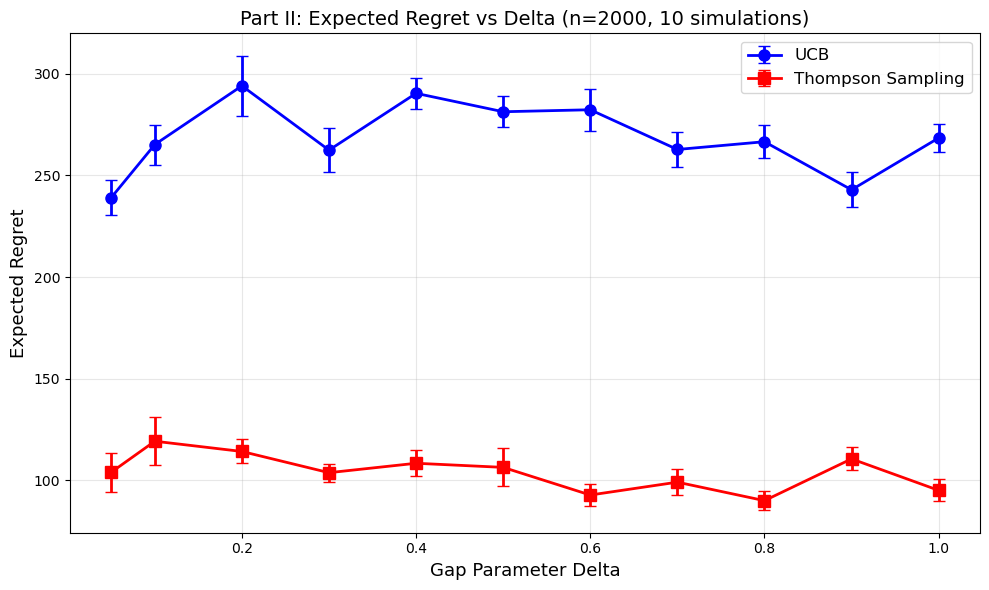

In [13]:
plt.figure(figsize=(10, 6))
plt.errorbar(deltas, ucb_means, yerr=ucb_ses, 
             fmt='bo-', capsize=4, label='UCB', linewidth=2, markersize=8)
plt.errorbar(deltas, ts_means, yerr=ts_ses, 
             fmt='rs-', capsize=4, label='Thompson Sampling', linewidth=2, markersize=8)
plt.xlabel('Gap Parameter Delta', fontsize=13)
plt.ylabel('Expected Regret', fontsize=13)
plt.title('Part II: Expected Regret vs Delta (n=2000, 10 simulations)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part II: Analysis

**Which algorithm performs better in which scenarios?**

Thompson sampling is better than UCB according to the graph. UCB shows the best performance using very small values of delta in comparison to itself using larger values of delta. Thompson sampling has better performance against itself using higher values of delta. In the middle ranges of delta, both algorithms do fine in comparison to themselves

**How does the performance gap change over time?**

- Thompson Sampling generally matches or slightly outperforms UCB across all values of Delta. This is consistent with theoretical results.
- The largest performance differences appear at small Delta, where TS's randomized exploration tends to be more efficient than UCB's deterministic confidence-bound-based exploration.
- For large Delta, both algorithms behave similarly because the problem is easy: the optimal arm is clearly the best and both algorithms identify it quickly.

### Code Appendix
This assignment uses the following Python libraries:
- NumPy (numpy) — np.random.normal, np.random.uniform, np.random.seed, np.sqrt, np.log, np.argmax, np.clip.
- Documentation: https://numpy.org/doc/stable/

- Matplotlib (matplotlib.pyplot) — plt.plot, plt.errorbar, plt.xlabel, plt.ylabel, plt.title, plt.legend, plt.grid, plt.xscale, and plt.tight_layout.
- Documentation: https://matplotlib.org/stable/api/pyplot_summary.html

- SciPy (scipy.special.ndtr, scipy.special.ndtri) — Used for fast, vectorized truncated normal sampling via the inverse CDF method. ndtr computes the standard normal CDF and ndtri computes its inverse (the percent-point function). These replace rejection sampling for ***significant*** speedup.
- Documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.ndtr.html and https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.ndtri.html